# Inventor countries — Validation & Visualization (PatentsView)

Face-validity figures for `PatentView/output/patent_inventor_country.parquet`, the
inventor-country table written by `PatentView/notebook/patent_inventor_country.ipynb`, read
against the sibling patent metric tables:

1. **Coverage** — located inventors and located assignees by grant year, and by team size.
2. **Country composition, and inventor against assignee country** — full and fractional
   counting; how often the first inventor sits in a country the patent is assigned to.
3. **International co-invention** — share of multi-country patents by grant year and team size.
4. **Internationality, impact and disruption** — citation percentile and CD by number of
   countries, within team-size bands.
5. **Country pairs** — co-invention partners, 2010–2020.
6. **Country profiles and technology mix** — internationality against impact and disruption,
   plus the CPC-section composition that partly drives it.
7. **Papers against patents** — the OpenAlex author-country table side by side.

## What the country of a patent is here
The country of an inventor is the country of the **address printed on that grant**, not the
inventor's current or most frequent location: a patent is a dated document and its addresses are
contemporaneous, which is what makes the time series in §2 meaningful. `assignee_countries` is
the same construction over the disambiguated assignees, and the two answer different questions —
where the invention was made, and who owns it (§2, right panel).

Coverage is high (99.3% of patents have a located inventor) because a US grant must print an
address, so unlike the paper side almost nothing is conditioned away. The exception is the
1970s, where the disambiguated location table is thinner.

## Inputs
`patent_inventor_country`, `patent_metadata` (grant year, primary CPC), `patent_hit_probability`
(`pctl_c10`), `patent_disruption` (`CD_5`). §7 reads the OpenAlex author-country table, through
the base table `author_country_validation` §0 writes when it is present, and is skipped
otherwise. Everything here is 8.5M rows; it runs in a few minutes.

In [1]:
import os, sys, time, duckdb
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

sys.path.insert(0, '/project/jevans/Dawoon/Science of Science/validation')
import val_common as V
V.init('inventor_country_validation'); V.preflight()

Q = V.patent
IC   = Q('patent_inventor_country.parquet')
META = Q('patent_metadata.parquet')
HIT  = Q('patent_hit_probability.parquet')
DISR = Q('patent_disruption.parquet')
PAPER_BASE = os.environ.get('NB_BASE_FP', f'{V.VAL}/data/author_country_base.parquet')   # written by author_country_validation
PAPER_AC, PAPER_META = V.paper('paper_author_country.parquet'), V.paper('paper_metadata.parquet')
YMIN, YMAX = 1976, 2025

con = duckdb.connect()
con.execute(f"SET memory_limit='{os.environ.get('NB_DUCKDB_MEM', '150GB')}'")
con.execute(f"SET temp_directory='{V.TMP}'")
con.execute("SET preserve_insertion_order=false")
con.execute("SET enable_progress_bar=false")

C1, C2, C3, C4 = '#4E2A84', '#F7602A', '#2a78d6', '#3aa17e'      # the palette the sibling validation notebooks use
# Magnitude is a SINGLE hue, light -> dark; polarity is two opposite-temperature hues with a
# neutral middle. No rainbow ramp anywhere: on a choropleth a multi-hue ramp invents regions.
SEQ, DIV = 'Blues', 'RdBu_r'
# NODATA has to be told apart from BOTH the pale end of the sequential ramp and the near-white
# middle of the diverging one, so it is a grey with no blue in it rather than a light tint.
INK, MUTED, NODATA, LAND = '#1f2933', '#6b7280', '#cfd2d6', '#dfe4ea'
BANDS = [(2, 3, '2-3'), (4, 6, '4-6'), (7, 10, '7-10'), (11, 10**6, '11+')]
BAND_ORDER = [l for _, _, l in BANDS]
BAND_SQL = "CASE " + " ".join(f"WHEN team_size BETWEEN {a} AND {b} THEN '{l}'" for a, b, l in BANDS) + " END"

def clean(ax):
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False); ax.grid(alpha=0.25)

def ci95(std, n):
    """95% CI half-width of a mean. std/n come straight from SQL, so both can be null."""
    std = pd.to_numeric(std, errors='coerce').fillna(0).to_numpy(float)
    n = pd.to_numeric(n, errors='coerce').fillna(0).to_numpy(float)
    return 1.96 * std / np.sqrt(np.maximum(n, 1))

def pair_heatmap(pairs, top, title, ax, cbar_label="% of A's international documents with B"):
    """pairs: DataFrame (c1, c2, n) over UNORDERED pairs, c1 < c2.

    Row-normalised, so the matrix is NOT symmetric: cell (A, B) is the share of A's
    international documents that involve B. Reading it the other way round would say that a
    small country and the US collaborate equally often, which is the opposite of the fact.
    """
    top = list(top)
    m = pd.DataFrame(0.0, index=top, columns=top)
    tot = {}
    for c1, c2, n in pairs[['c1', 'c2', 'n']].itertuples(index=False):
        tot[c1] = tot.get(c1, 0) + n
        tot[c2] = tot.get(c2, 0) + n
        if c1 in m.index and c2 in m.columns:
            m.loc[c1, c2] += n
            m.loc[c2, c1] += n
    share = m.div(pd.Series({c: tot.get(c, 1) or 1 for c in top}), axis=0) * 100
    im = ax.imshow(share.to_numpy(), cmap=SEQ, aspect='auto')
    ax.set_xticks(range(len(top))); ax.set_xticklabels(top, rotation=90, fontsize=8)
    ax.set_yticks(range(len(top))); ax.set_yticklabels(top, fontsize=8)
    vals = share.to_numpy()
    hi = vals.max() or 1
    for i in range(len(top)):
        for j in range(len(top)):
            # ink on the light end, white on the dark end -- one fixed colour would be
            # unreadable at one end of a light-to-dark ramp
            if i != j and vals[i, j] >= 8:
                ax.text(j, i, f'{vals[i, j]:.0f}', ha='center', va='center', fontsize=6,
                        color=('white' if vals[i, j] > 0.55 * hi else INK))
    ax.set_title(title, fontsize=10); ax.set_ylabel('country A'); ax.set_xlabel('partner B')
    plt.colorbar(im, ax=ax, fraction=0.04, label=cbar_label)
    return share

def spearman(a, b):
    from scipy.stats import spearmanr
    return spearmanr(a, b).correlation


# --- world maps -------------------------------------------------------------------------
# Boundaries: validation/data/world_countries.geojson, Natural Earth 1:50m Admin 0 (public
# domain), trimmed to iso2/name/continent and simplified; see world_countries.source.json.
# The 1:50m cut is deliberate -- 1:110m omits Singapore, Hong Kong, Malta and Bahrain, all of
# which are real producers here, and a country missing from the map reads as a country with no
# output. Robinson, because an equirectangular world map inflates the high latitudes and this
# figure is about how much each country produces.
WORLD_FP = f'{V.VAL}/data/world_countries.geojson'
ROBINSON = '+proj=robin +lon_0=0 +datum=WGS84 +units=m +no_defs'

def load_world():
    """(GeoDataFrame in Robinson, {iso2: (lon, lat)}) or (None, None) if the file is absent."""
    try:
        import geopandas as gpd
    except ImportError:
        print('geopandas is not installed -- map sections skipped'); return None, None
    if not os.path.exists(WORLD_FP):
        print(f'{WORLD_FP} is missing -- map sections skipped.\n'
              '  Rebuild it from Natural Earth 1:50m Admin 0 Countries; see world_countries.source.json.')
        return None, None
    w = gpd.read_file(WORLD_FP)

    def rep(g):
        # the representative point of the LARGEST polygon, so the United States lands in the
        # lower 48 and France in France rather than in Alaska or French Guiana
        p = max(g.geoms, key=lambda q: q.area) if g.geom_type == 'MultiPolygon' else g
        return p.representative_point()

    pts = {r.iso2: (rep(r.geometry).x, rep(r.geometry).y) for r in w.itertuples()}
    return w.to_crs(ROBINSON), pts

def frame(ax, world):
    """Every panel gets the same extent, so the four maps are comparable and a stray arc is clipped."""
    x0, y0, x1, y1 = world.total_bounds
    mx, my = 0.02 * (x1 - x0), 0.04 * (y1 - y0)
    ax.set_xlim(x0 - mx, x1 + mx); ax.set_ylim(y0 - my, y1 + my)
    ax.set_axis_off()

def choropleth(ax, world, values, title, label, cmap=SEQ, norm=None):
    """values: Series indexed by ISO2. Countries with no value are drawn in the no-data grey."""
    g = world.merge(values.rename('v'), left_on='iso2', right_index=True, how='left')
    g.plot(ax=ax, column='v', cmap=cmap, norm=norm, linewidth=0.2, edgecolor='white',
           legend=True, legend_kwds={'orientation': 'horizontal', 'shrink': 0.62, 'pad': 0.01,
                                     'aspect': 34, 'label': label},
           missing_kwds={'color': NODATA, 'edgecolor': 'white', 'linewidth': 0.2})
    ax.set_title(title, fontsize=10, color=INK); frame(ax, world)
    return g

def map_coverage(values, world, what):
    """Say out loud which codes in the data have no polygon, and how much output they carry."""
    have = set(world['iso2'])
    miss = values[[c not in have for c in values.index]]
    if len(miss):
        share = 100 * miss.sum() / values.sum() if values.sum() else 0
        print(f'  {len(miss)} {what} code(s) have no polygon on the map '
              f'({share:.2f}% of the total): {", ".join(sorted(miss.index)[:20])}')
    else:
        print(f'  every {what} code in the data is on the map')

def flowmap(ax, world, pts, pairs, title, topn=70, label_top=10):
    """Great-circle arcs between country representative points, width ~ sqrt(volume)."""
    import geopandas as gpd
    from shapely.geometry import LineString
    from pyproj import Geod
    geod = Geod(ellps='WGS84')
    world.plot(ax=ax, color=LAND, edgecolor='white', linewidth=0.35)
    top = pairs.nlargest(topn, 'n')
    segs, wts, dropped = [], [], 0
    for c1, c2, n in top[['c1', 'c2', 'n']].itertuples(index=False):
        if c1 not in pts or c2 not in pts:
            dropped += 1; continue
        (x1, y1), (x2, y2) = pts[c1], pts[c2]
        coords = [(x1, y1)] + geod.npts(x1, y1, x2, y2, 60) + [(x2, y2)]
        run = [coords[0]]
        for p, q in zip(coords, coords[1:]):
            if abs(q[0] - p[0]) > 180:          # the arc crosses the antimeridian: cut it
                if len(run) > 1: segs.append(LineString(run)); wts.append(n)
                run = [q]
            else:
                run.append(q)
        if len(run) > 1: segs.append(LineString(run)); wts.append(n)
    if not segs:
        print('  no drawable pairs'); return
    gl = gpd.GeoDataFrame({'n': wts}, geometry=segs, crs='EPSG:4326').to_crs(ROBINSON)
    hi = gl.n.max()
    gl.plot(ax=ax, color=C1, linewidth=0.35 + 3.6 * np.sqrt(gl.n / hi), alpha=0.45)
    deg = pd.concat([top.groupby('c1').n.sum(), top.groupby('c2').n.sum()]).groupby(level=0).sum()
    named = gpd.GeoSeries.from_xy(*zip(*[pts[c] for c in deg.nlargest(label_top).index
                                         if c in pts]), crs='EPSG:4326').to_crs(ROBINSON)
    for code, p in zip([c for c in deg.nlargest(label_top).index if c in pts], named):
        ax.plot(p.x, p.y, 'o', ms=3, color=INK, zorder=5)
        ax.annotate(code, (p.x, p.y), fontsize=8, color=INK, zorder=6,
                    xytext=(4, 3), textcoords='offset points')
    ax.set_title(title, fontsize=10, color=INK)
    # A near-antipodal pair has a great circle that sweeps over a pole and far outside the
    # Robinson outline; clipping to the map keeps the map the size of the map.
    frame(ax, world)
    if dropped:
        print(f'  {dropped} of the top {topn} pairs involve a country with no polygon and are not drawn')

[val] inventor_country_validation  ->  /project/jevans/Dawoon/Science of Science/validation/Figures/inventor_country_validation_<section>.{jpg,pdf}  @ 600 dpi
  inventor_country_validationOK


## 0. Base table and integrity

One row per patent of `patent_inventor_country`, with `grant_year` and the CPC **section** (the
first letter of the primary CPC group) from `patent_metadata`, `pctl_c10` from
`patent_hit_probability` and `CD_5` from `patent_disruption`. 8.5M rows, held as a DuckDB table
rather than written to disk.

`team_size_meta` recomputes the inventor count from `patent_metadata.inventor_list` as an
independent check. The split is on `;` **followed by the start of the next id** — 36 patents
carry a PatentsView inventor id with a semicolon of its own (`fl:iv_ln:jadri&cacute;-1`,
`fl:jo_ln:ha;feld-1`), and splitting on a bare `;` counts those patents as having extra
inventors.

In [2]:
%%time
t0 = time.time()
con.execute(f"""
CREATE OR REPLACE TABLE base AS
SELECT i.patent_id,
       i.n_inventors AS team_size, i.n_located, i.n_countries, i.countries,
       i.country_inventor_counts, i.first_inventor_country, i.is_international, i.assignee_countries,
       m.grant_year, m.cpc_section, m.team_size_meta,
       h.pctl_c10, d.CD_5
FROM read_parquet('{IC}') i
LEFT JOIN (
  SELECT patent_id, grant_year, left(cpc_code, 1) AS cpc_section,
         len(str_split(regexp_replace(inventor_list, ';(fl:|[0-9a-z]{{20}})', '|\\1', 'g'), '|')) AS team_size_meta
  FROM read_parquet('{META}')) m USING (patent_id)
LEFT JOIN read_parquet('{HIT}')  h USING (patent_id)
LEFT JOIN read_parquet('{DISR}') d USING (patent_id)""")
s = con.execute("""
SELECT count(*) AS patents, count(grant_year) AS with_year, sum(team_size) AS inventor_slots,
       sum(n_located) AS located_slots, count(countries) AS with_country,
       count(*) FILTER (WHERE n_countries > 1) AS international,
       count(assignee_countries) AS with_assignee_country,
       count(pctl_c10) AS with_hit, count(CD_5) AS with_cd5,
       count(*) FILTER (WHERE n_located > team_size)                                        AS bad_located,
       count(*) FILTER (WHERE (n_countries > 0) <> (countries IS NOT NULL))                 AS bad_country_flag,
       count(*) FILTER (WHERE is_international <> (n_countries > 1))                        AS bad_intl_flag,
       count(*) FILTER (WHERE team_size_meta IS NOT NULL AND team_size_meta <> team_size)   AS team_size_mismatch
FROM base""").fetchdf().iloc[0]
for k, v in s.items():
    print(f'  {k:<22} {int(v):>15,}')
ok = all(s[k] == 0 for k in ['bad_located', 'bad_country_flag', 'bad_intl_flag', 'team_size_mismatch'])
print(f"\n  located patents {s.with_country/s.patents*100:.1f}%   located inventor slots {s.located_slots/s.inventor_slots*100:.1f}%   "
      f"international {s.international/s.patents*100:.1f}%")
print(f"  integrity of the input table: {'ALL PASS' if ok else 'FAILED -- see bad_* above'}   [{time.time()-t0:.0f}s]")

  patents                      8,531,216
  with_year                    8,531,216
  inventor_slots              22,318,528
  located_slots               22,159,610
  with_country                 8,474,359
  international                  539,323
  with_assignee_country        7,665,816
  with_hit                     8,511,970
  with_cd5                     5,767,579
  bad_located                          0
  bad_country_flag                     0
  bad_intl_flag                        0
  team_size_mismatch                   0

  located patents 99.3%   located inventor slots 99.3%   international 6.3%
  integrity of the input table: ALL PASS   [4s]
CPU times: user 19.9 s, sys: 791 ms, total: 20.7 s
Wall time: 4.38 s


## 1. Coverage

Left: share of patents with ≥ 1 located inventor, share of inventor slots located, and share
with a located assignee, by grant year. Assignee coverage is structurally lower — a patent owned
by its inventors has no assignee row at all, so the gap between the two curves is the
individually-owned share, not missing data.

Right: the team-size distribution of located and unlocated patents. If they had different
shapes, the located subset would not be representative and every later section would be
conditioned on something; they should be close.

  [fig] inventor_country_validation_1.jpg + .pdf  (600 dpi)


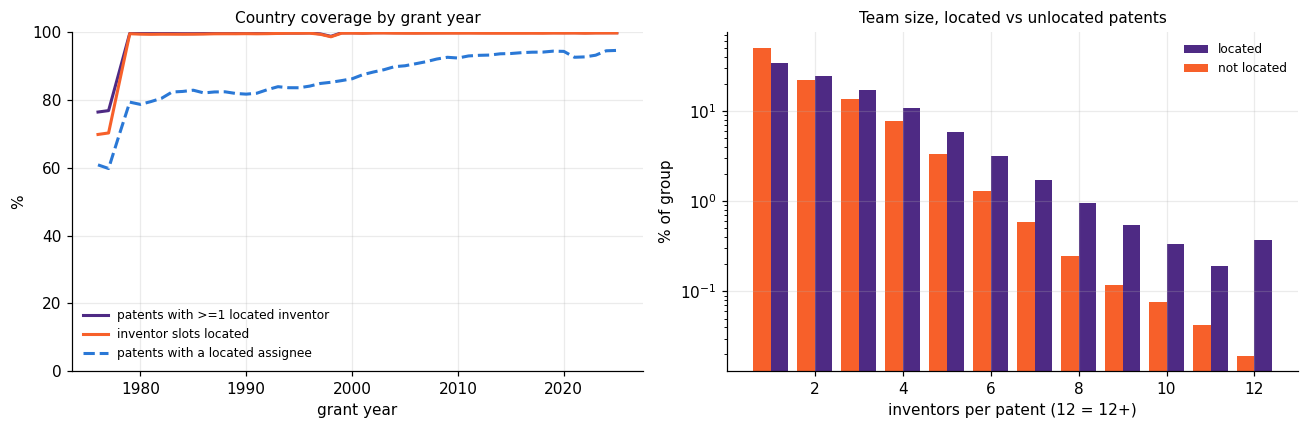

                 n  pct_pat  pct_slots  pct_asg
grant_year                                     
1976         70165     76.4       69.8     60.9
1980         61783     99.6       99.4     78.7
1990         90347     99.7       99.6     81.7
2000        157588     99.8       99.7     86.2
2010        219848     99.9       99.7     92.4
2020        353701     99.9       99.7     94.3
CPU times: user 2.03 s, sys: 191 ms, total: 2.22 s
Wall time: 1.68 s


In [3]:
%%time
cov = con.execute(f"""
SELECT grant_year, count(*) AS n,
       100.0*count(countries)/count(*) AS pct_pat,
       100.0*sum(n_located)/nullif(sum(team_size), 0) AS pct_slots,
       100.0*count(assignee_countries)/count(*) AS pct_asg
FROM base WHERE grant_year BETWEEN {YMIN} AND {YMAX} GROUP BY 1 ORDER BY 1""").fetchdf()
ts = con.execute("""
SELECT least(team_size, 12) AS k, countries IS NOT NULL AS located, count(*) AS n
FROM base GROUP BY 1, 2 ORDER BY 1, 2""").fetchdf()

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(cov.grant_year, cov.pct_pat, color=C1, lw=2, label='patents with >=1 located inventor')
ax[0].plot(cov.grant_year, cov.pct_slots, color=C2, lw=2, label='inventor slots located')
ax[0].plot(cov.grant_year, cov.pct_asg, color=C3, lw=2, ls='--', label='patents with a located assignee')
ax[0].set_ylim(0, 100); ax[0].set_xlabel('grant year'); ax[0].set_ylabel('%')
ax[0].legend(frameon=False, fontsize=8); clean(ax[0]); ax[0].set_title('Country coverage by grant year', fontsize=10)
for loc, col, lab in [(True, C1, 'located'), (False, C2, 'not located')]:
    g = ts[ts.located == loc]
    ax[1].bar(g.k + (0.2 if loc else -0.2), 100 * g.n / max(g.n.sum(), 1), 0.4, color=col, label=lab)
ax[1].set_yscale('log'); ax[1].set_xlabel('inventors per patent (12 = 12+)')
ax[1].set_ylabel('% of group'); ax[1].legend(frameon=False, fontsize=8); clean(ax[1])
ax[1].set_title('Team size, located vs unlocated patents', fontsize=10)
V.save('1')
print(cov.set_index('grant_year').reindex([y for y in (1976, 1980, 1990, 2000, 2010, 2020) if y in set(cov.grant_year)]).round(1).to_string())

## 2. Country composition, and inventor against assignee

Left: the ten largest inventor countries by grant year, full counting, as a share of located
patents — the well-known story of the US share falling as Japan, then Korea, Taiwan and China
rise. Middle: full against fractional share, 2010–2020. Right: among patents with both a located
first inventor and a located assignee, the share whose first inventor's country is one of the
assignee countries. The complement is foreign-owned invention, and its trend is the
globalisation of R&D as seen from inside the patent record.

  [fig] inventor_country_validation_2.jpg + .pdf  (600 dpi)


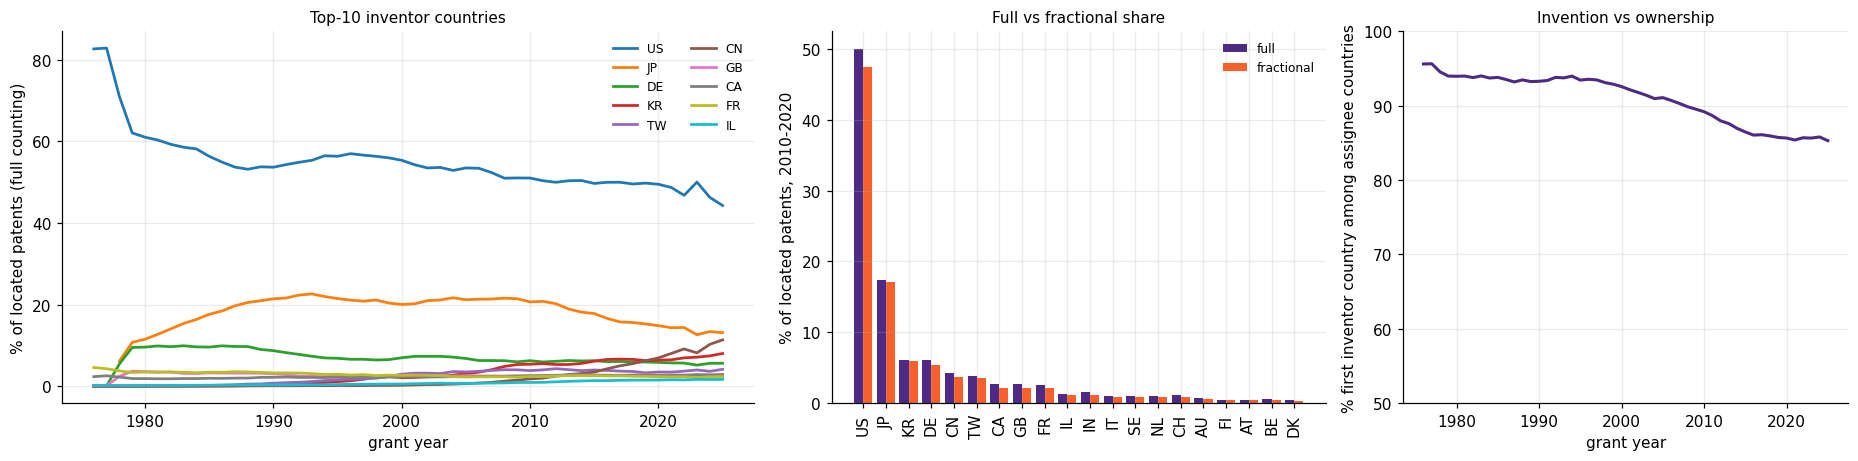

country  full_share  frac_share
     US       49.98       47.45
     JP       17.41       17.06
     KR        6.06        5.93
     DE        6.09        5.35
     CN        4.22        3.74
     TW        3.81        3.62
     CA        2.71        2.21
     GB        2.70        2.12
     FR        2.51        2.12
     IL        1.34        1.17
     IN        1.55        1.15
     IT        1.04        0.89
     SE        1.01        0.85
     NL        1.04        0.83
     CH        1.11        0.82
     AU        0.72        0.59
     FI        0.52        0.45
     AT        0.52        0.41
     BE        0.57        0.39
     DK        0.40        0.34
CPU times: user 31.1 s, sys: 327 ms, total: 31.4 s
Wall time: 6.53 s


In [4]:
%%time
full = con.execute(f"""
SELECT grant_year, c AS country, count(*) AS n
FROM base, unnest(str_split(countries, ';')) AS u(c)
WHERE countries IS NOT NULL AND grant_year BETWEEN {YMIN} AND {YMAX} GROUP BY 1, 2""").fetchdf()
den = con.execute(f"""
SELECT grant_year, count(countries) AS located FROM base
WHERE grant_year BETWEEN {YMIN} AND {YMAX} GROUP BY 1 ORDER BY 1""").fetchdf().set_index('grant_year')['located']
top10 = full[full.grant_year.between(2000, 2020)].groupby('country').n.sum().nlargest(10).index.tolist()
frac = con.execute("""
WITH x AS (
  SELECT list_transform(str_split(country_inventor_counts, ';'), s -> str_split(s, ':')) AS L
  FROM base WHERE country_inventor_counts IS NOT NULL AND grant_year BETWEEN 2010 AND 2020),
y AS (SELECT L, list_sum(list_transform(L, z -> z[2]::INTEGER)) AS tot FROM x)
SELECT z[1] AS country, sum(z[2]::INTEGER / tot) AS frac_n, count(*) AS full_n
FROM y, unnest(L) AS u(z) WHERE tot > 0 GROUP BY 1""").fetchdf()
n_loc = con.execute("SELECT count(countries) FROM base WHERE grant_year BETWEEN 2010 AND 2020").fetchone()[0]
frac['frac_share'] = 100 * frac.frac_n / frac.frac_n.sum()
frac['full_share'] = 100 * frac.full_n / max(n_loc, 1)
top20 = frac.nlargest(20, 'frac_n')
agree = con.execute(f"""
SELECT grant_year, count(*) AS n,
       100.0*avg(CASE WHEN list_contains(str_split(assignee_countries, ';'), first_inventor_country)
                      THEN 1.0 ELSE 0.0 END) AS same
FROM base
WHERE first_inventor_country IS NOT NULL AND assignee_countries IS NOT NULL
  AND grant_year BETWEEN {YMIN} AND {YMAX} GROUP BY 1 ORDER BY 1""").fetchdf()

fig, ax = plt.subplots(1, 3, figsize=(17, 4.3), gridspec_kw={'width_ratios': [1.4, 1, 0.9]})
cmap = plt.get_cmap('tab10')
for i, c in enumerate(top10):
    g = full[full.country == c].set_index('grant_year').n.reindex(den.index)
    ax[0].plot(den.index, 100 * g / den, lw=1.8, color=cmap(i), label=c)
ax[0].set_xlabel('grant year'); ax[0].set_ylabel('% of located patents (full counting)')
ax[0].legend(ncol=2, fontsize=8, frameon=False); clean(ax[0])
ax[0].set_title('Top-10 inventor countries', fontsize=10)
xs = np.arange(len(top20))
ax[1].bar(xs - 0.2, top20.full_share, 0.4, color=C1, label='full')
ax[1].bar(xs + 0.2, top20.frac_share, 0.4, color=C2, label='fractional')
ax[1].set_xticks(xs); ax[1].set_xticklabels(top20.country, rotation=90)
ax[1].set_ylabel('% of located patents, 2010-2020'); ax[1].legend(frameon=False, fontsize=8); clean(ax[1])
ax[1].set_title('Full vs fractional share', fontsize=10)
ax[2].plot(agree.grant_year, agree.same, color=C1, lw=2)
ax[2].set_ylim(50, 100); ax[2].set_xlabel('grant year')
ax[2].set_ylabel('% first inventor country among assignee countries'); clean(ax[2])
ax[2].set_title('Invention vs ownership', fontsize=10)
V.save('2')
print(top20[['country', 'full_share', 'frac_share']].round(2).to_string(index=False))

## 3. International co-invention

Share of patents whose located inventors span ≥ 2 countries, over located patents with ≥ 2
inventors, by grant year and team-size band; and the number-of-countries distribution for
2010–2020. Cross-border co-invention is rarer than cross-border co-authorship by a wide margin —
a patent is a legal instrument filed by one owner, and inventor teams are assembled inside
firms — so a share far above the paper side in §7 would be the signal that something is wrong.

  [fig] inventor_country_validation_3.jpg + .pdf  (600 dpi)


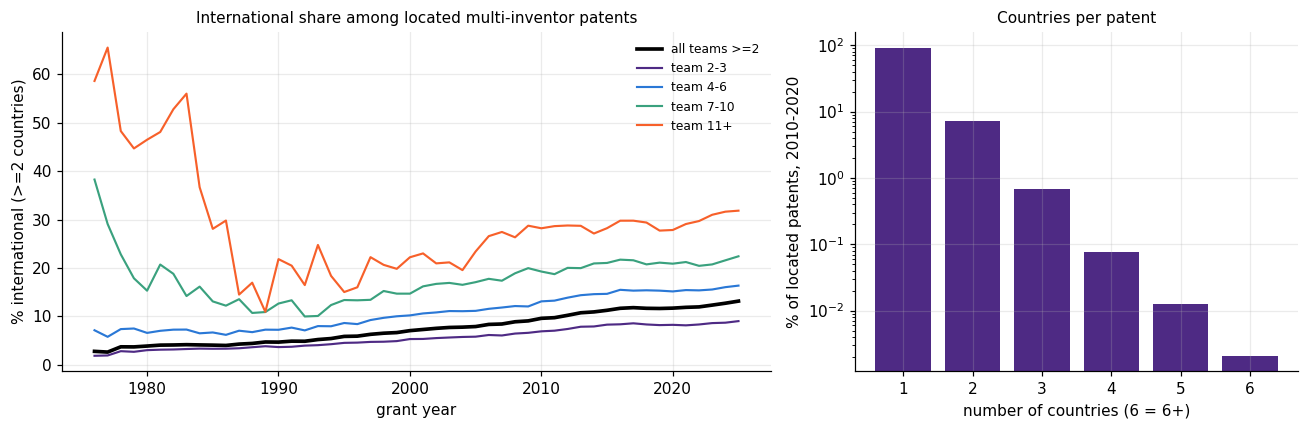

                 n   pct
grant_year              
1980         26722   3.9
1990         47133   4.7
2000         93980   7.0
2010        148150   9.6
2020        260789  11.7
CPU times: user 2.3 s, sys: 48.9 ms, total: 2.34 s
Wall time: 1.58 s


In [5]:
%%time
q_intl = """
SELECT grant_year, {band} AS band, count(*) AS n,
       100.0*count(*) FILTER (WHERE n_countries > 1)/count(*) AS pct
FROM base WHERE countries IS NOT NULL AND team_size >= 2 AND grant_year BETWEEN {y0} AND {y1}
GROUP BY 1, 2 ORDER BY 1"""
intl_all = con.execute(q_intl.format(band="'all'", y0=YMIN, y1=YMAX)).fetchdf()
intl_band = con.execute(q_intl.format(band=BAND_SQL, y0=YMIN, y1=YMAX)).fetchdf()
dist = con.execute("""
SELECT least(n_countries, 6) AS k, count(*) AS n FROM base
WHERE countries IS NOT NULL AND grant_year BETWEEN 2010 AND 2020 GROUP BY 1 ORDER BY 1""").fetchdf()

fig, ax = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={'width_ratios': [1.6, 1]})
ax[0].plot(intl_all.grant_year, intl_all.pct, lw=2.4, color='black', label='all teams >=2')
for lab, col in zip(BAND_ORDER, [C1, C3, C4, C2]):
    g = intl_band[intl_band.band == lab]
    if len(g):
        ax[0].plot(g.grant_year, g.pct, lw=1.4, color=col, label=f'team {lab}')
ax[0].set_xlabel('grant year'); ax[0].set_ylabel('% international (>=2 countries)')
ax[0].legend(frameon=False, fontsize=8); clean(ax[0])
ax[0].set_title('International share among located multi-inventor patents', fontsize=10)
ax[1].bar(dist.k, 100 * dist.n / dist.n.sum(), color=C1); ax[1].set_yscale('log')
ax[1].set_xlabel('number of countries (6 = 6+)'); ax[1].set_ylabel('% of located patents, 2010-2020'); clean(ax[1])
ax[1].set_title('Countries per patent', fontsize=10)
V.save('3')
print(intl_all.set_index('grant_year').reindex([y for y in (1980, 1990, 2000, 2010, 2020) if y in set(intl_all.grant_year)])[['n', 'pct']].round(1).to_string())

## 4. Internationality against impact and disruption

Mean within-(WIPO sector, grant year) 10-year citation percentile, top-10% share and mean
`CD_5` by the number of inventor countries, within team-size bands, grant years 1990–2015.
The same design as the paper notebook's §4, on the same metrics, so the two are directly
comparable.

  [fig] inventor_country_validation_4.jpg + .pdf  (600 dpi)


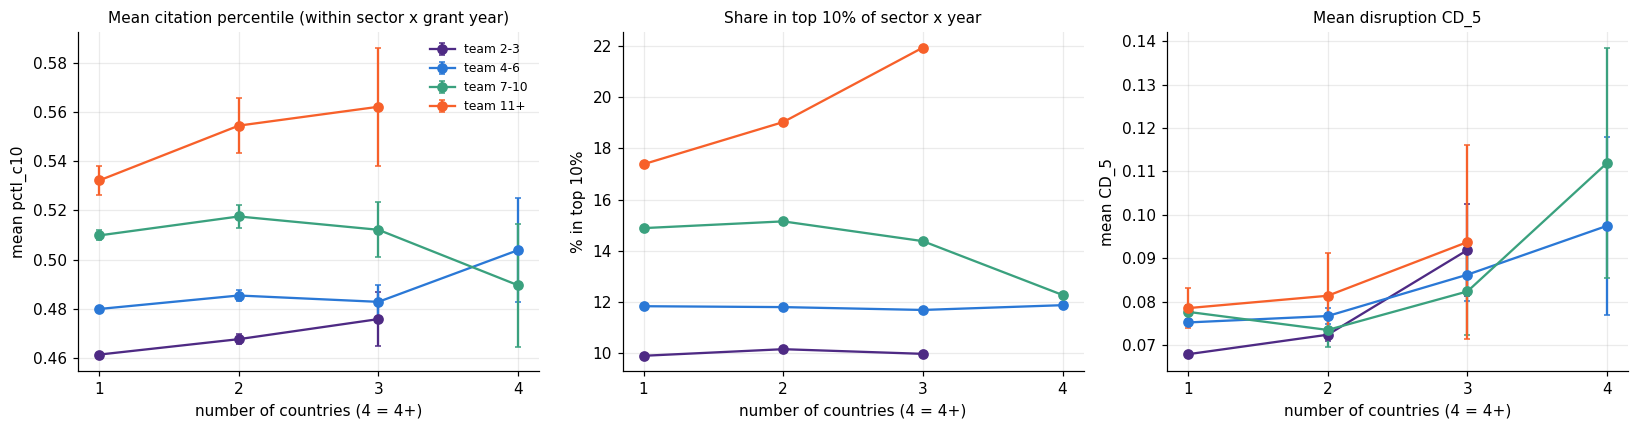

band     11+     2-3     4-6    7-10
k                                   
1     0.5322  0.4613  0.4799  0.5098
2     0.5545  0.4676  0.4854  0.5175
3     0.5622  0.4758  0.4828  0.5121
4        NaN     NaN  0.5038  0.4895

band     11+     2-3     4-6    7-10
k                                   
1     0.0785  0.0679  0.0752  0.0776
2     0.0814  0.0724  0.0767  0.0735
3     0.0937  0.0919  0.0862  0.0824
4        NaN     NaN  0.0975  0.1119
CPU times: user 1.68 s, sys: 55.9 ms, total: 1.74 s
Wall time: 1.45 s


In [6]:
%%time
imp = con.execute(f"""
SELECT {BAND_SQL} AS band, least(n_countries, 4) AS k, count(*) AS n,
       avg(pctl_c10) AS hit, stddev(pctl_c10) AS hit_sd,
       avg(CD_5) AS cd, stddev(CD_5) AS cd_sd, count(CD_5) AS n_cd,
       100.0*avg(CASE WHEN pctl_c10 >= 0.9 THEN 1.0 ELSE 0.0 END) AS top10
FROM base
WHERE countries IS NOT NULL AND team_size >= 2 AND grant_year BETWEEN 1990 AND 2015 AND pctl_c10 IS NOT NULL
GROUP BY 1, 2 HAVING count(*) >= 500 ORDER BY 1, 2""").fetchdf()

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
for lab, col in zip(BAND_ORDER, [C1, C3, C4, C2]):
    g = imp[imp.band == lab]
    if not len(g):
        continue
    ax[0].errorbar(g.k, g.hit, yerr=ci95(g.hit_sd, g.n), marker='o', color=col, label=f'team {lab}', capsize=2)
    ax[1].plot(g.k, g.top10, marker='o', color=col, label=f'team {lab}')
    ax[2].errorbar(g.k, g.cd, yerr=ci95(g.cd_sd, g.n_cd), marker='o', color=col, label=f'team {lab}', capsize=2)
for a, t, yl in zip(ax, ['Mean citation percentile (within sector x grant year)', 'Share in top 10% of sector x year',
                         'Mean disruption CD_5'],
                    ['mean pctl_c10', '% in top 10%', 'mean CD_5']):
    a.set_xlabel('number of countries (4 = 4+)'); a.set_ylabel(yl); a.set_title(t, fontsize=10)
    a.set_xticks([1, 2, 3, 4]); clean(a)
ax[0].legend(frameon=False, fontsize=8)
V.save('4')
print(imp.pivot(index='k', columns='band', values='hit').round(4).to_string())
print()
print(imp.pivot(index='k', columns='band', values='cd').round(4).to_string())

## 5. Country pairs, 2010–2020

Unordered pairs of inventor countries on patents with 2–5 countries, row-normalised over the 15
countries with the most international patents, exactly as in the paper notebook's §5: cell
(A, B) is the share of A's international patents that involve B.

  [fig] inventor_country_validation_5.jpg + .pdf  (600 dpi)


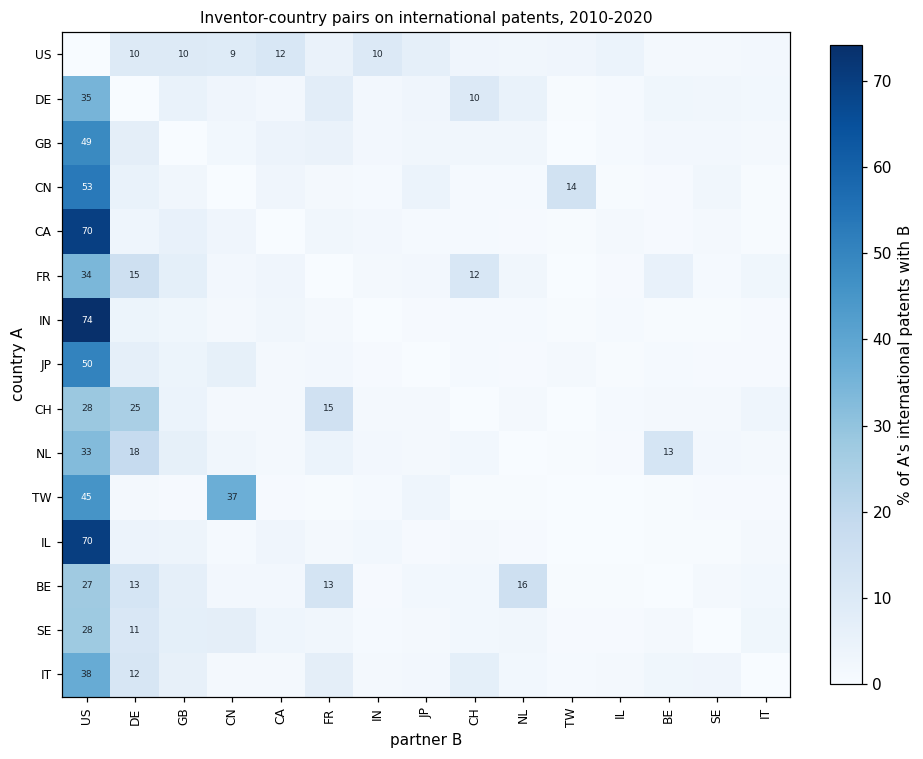

c1 c2     n
CA US 22295
IN US 19458
GB US 19029
DE US 18928
CN US 17752
JP US 12564
FR US  9287
IL US  8495
CH US  6031
TW US  5904
CH DE  5394
NL US  4820
CN TW  4811
KR US  4299
AU US  4152
CPU times: user 4.19 s, sys: 662 ms, total: 4.85 s
Wall time: 4.67 s


In [7]:
%%time
pairs = con.execute("""
WITH p AS (
  SELECT patent_id, str_split(countries, ';') AS L
  FROM base WHERE grant_year BETWEEN 2010 AND 2020 AND n_countries BETWEEN 2 AND 5),
e AS (SELECT patent_id, u.c AS c FROM p, unnest(p.L) AS u(c))
SELECT a.c AS c1, b.c AS c2, count(*) AS n
FROM e a JOIN e b ON a.patent_id = b.patent_id AND a.c < b.c
GROUP BY 1, 2""").fetchdf()
if not len(pairs):
    print('[skip 5] no international patents in 2010-2020')
else:
    deg = pd.concat([pairs.groupby('c1').n.sum(), pairs.groupby('c2').n.sum()]).groupby(level=0).sum()
    top15 = deg.nlargest(15).index.tolist()
    fig, ax = plt.subplots(figsize=(8.5, 7))
    share5 = pair_heatmap(pairs, top15, 'Inventor-country pairs on international patents, 2010-2020', ax,
                          "% of A's international patents with B")
    V.save('5')
    print(pairs.nlargest(15, 'n').to_string(index=False))

## 6. Country profiles and technology mix, 2000–2015

Left and middle: the 25 countries with the most located patents — international share against
mean citation percentile and against mean `CD_5`. Right: the CPC-section composition of the ten
largest.

The right panel is there to keep the other two honest. Citation and disruption norms differ
sharply between CPC sections, and a country that patents mostly in one section will sit high or
low on the left for reasons that have nothing to do with its internationality. The percentile is
already computed within (WIPO sector, year), which absorbs much of this, but the mix is worth
seeing before any country-level claim is made.

  [fig] inventor_country_validation_6.jpg + .pdf  (600 dpi)


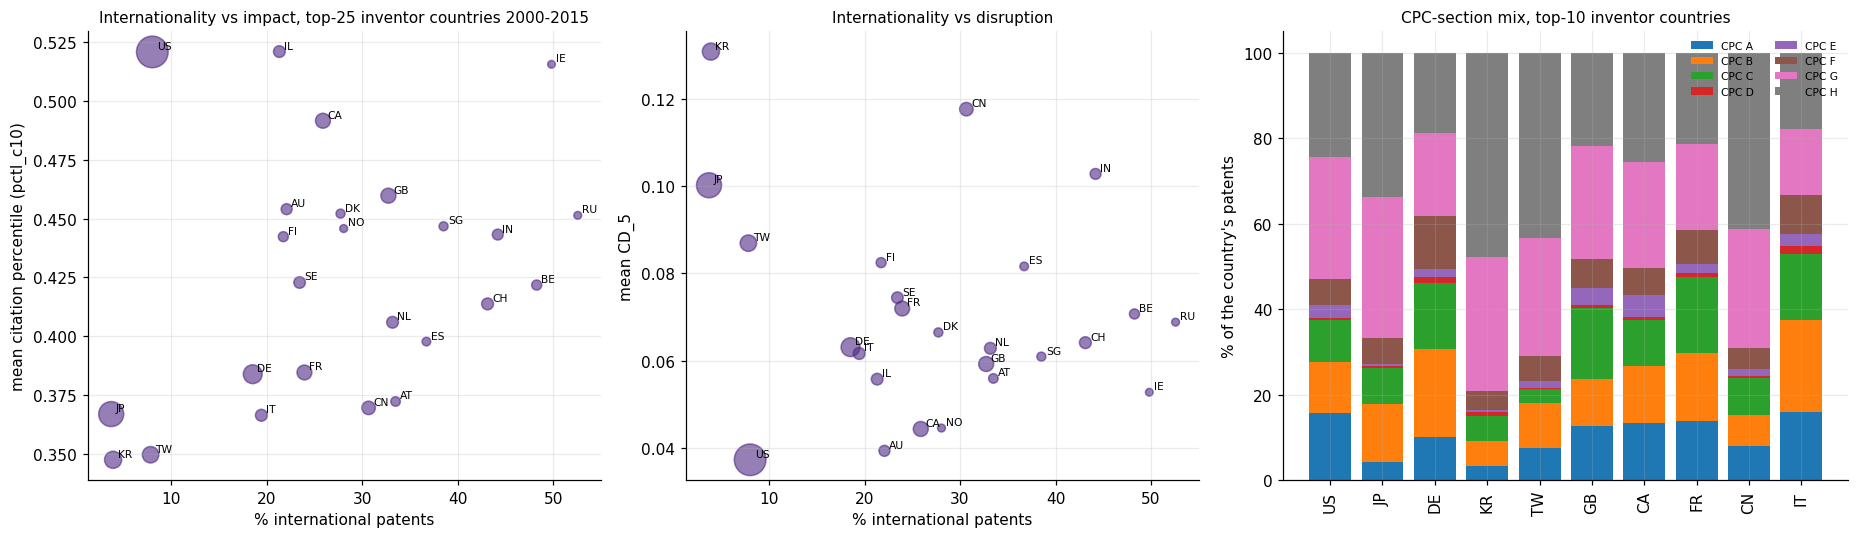

country       n   intl  team   hit    cd
     US 1652400  8.020 2.639 0.521 0.037
     JP  646182  3.714 2.671 0.367 0.100
     DE  207958 18.533 2.917 0.384 0.063
     KR  140875  3.912 2.956 0.348 0.131
     TW  120730  7.838 2.269 0.350 0.087
     GB   83376 32.740 2.826 0.460 0.059
     CA   82067 25.889 2.726 0.492 0.044
     FR   80219 23.949 2.786 0.385 0.072
     CN   54468 30.666 3.034 0.370 0.118
     IT   32891 19.440 2.643 0.366 0.062
     CH   32572 43.126 3.030 0.414 0.064
     NL   31323 33.177 2.980 0.406 0.063
     IL   30761 21.322 2.794 0.521 0.056
     SE   29344 23.443 2.516 0.423 0.074
     AU   23905 22.083 2.550 0.454 0.039
     IN   23123 44.194 3.547 0.443 0.103
     BE   17106 48.270 3.340 0.422 0.071
     FI   16727 21.737 2.579 0.442 0.082
     AT   13514 33.491 2.701 0.372 0.056
     DK   11049 27.731 2.796 0.452 0.066
     SG   10899 38.517 3.268 0.447 0.061
     ES    8990 36.719 3.254 0.398 0.082
     NO    6323 28.056 2.621 0.446 0.045
     RU    6184 

In [8]:
%%time
prof = con.execute("""
WITH x AS (
  SELECT c AS country, n_countries, team_size, pctl_c10, CD_5, cpc_section
  FROM base, unnest(str_split(countries, ';')) AS u(c)
  WHERE countries IS NOT NULL AND grant_year BETWEEN 2000 AND 2015)
SELECT country, count(*) AS n,
       100.0*avg(CASE WHEN n_countries > 1 THEN 1.0 ELSE 0.0 END) AS intl,
       avg(team_size) AS team, avg(pctl_c10) AS hit, avg(CD_5) AS cd
FROM x GROUP BY 1 ORDER BY n DESC LIMIT 25""").fetchdf()
top10c = prof.country.head(10).tolist()
mix = con.execute("""
WITH x AS (
  SELECT c AS country, cpc_section FROM base, unnest(str_split(countries, ';')) AS u(c)
  WHERE countries IS NOT NULL AND grant_year BETWEEN 2000 AND 2015 AND cpc_section IS NOT NULL)
SELECT country, cpc_section, count(*) AS n FROM x WHERE country IN ? GROUP BY 1, 2""", [top10c]).fetchdf()
mixp = mix.pivot(index='country', columns='cpc_section', values='n').fillna(0).reindex(top10c).fillna(0)
mixp = 100 * mixp.div(mixp.sum(axis=1).replace(0, np.nan), axis=0)

fig, ax = plt.subplots(1, 3, figsize=(17, 5), gridspec_kw={'width_ratios': [1, 1, 1.1]})
for a, ycol, yl in zip(ax[:2], ['hit', 'cd'], ['mean citation percentile (pctl_c10)', 'mean CD_5']):
    a.scatter(prof.intl, prof[ycol], s=np.sqrt(prof.n) / 3, color=C1, alpha=0.6)
    for _, r in prof.iterrows():
        a.annotate(r.country, (r.intl, r[ycol]), fontsize=7, xytext=(3, 2), textcoords='offset points')
    a.set_xlabel('% international patents'); a.set_ylabel(yl); clean(a)
ax[0].set_title('Internationality vs impact, top-25 inventor countries 2000-2015', fontsize=10)
ax[1].set_title('Internationality vs disruption', fontsize=10)
bottom = np.zeros(len(mixp)); cmap = plt.get_cmap('tab10')
for i, sec in enumerate(sorted(mixp.columns)):
    ax[2].bar(mixp.index, mixp[sec].to_numpy(), bottom=bottom, color=cmap(i % 10), label=f'CPC {sec}')
    bottom = bottom + mixp[sec].to_numpy()
ax[2].set_ylabel("% of the country's patents"); ax[2].legend(ncol=2, fontsize=7, frameon=False)
ax[2].tick_params(axis='x', rotation=90); clean(ax[2])
ax[2].set_title('CPC-section mix, top-10 inventor countries', fontsize=10)
V.save('6')
print(prof.round(3).to_string(index=False))

## 7. Papers against patents

The OpenAlex author-country table beside this one: coverage, international share among located
multi-author documents, and the number-of-countries distribution.

The two are different corpora located by different means — an institution match on an
affiliation string against an address printed on a grant — so the **levels** carry no
comparison. The shapes do: both should rise over the period, patents from a much higher coverage
base and to a much lower international share. If the patent series ever exceeded the paper
series on internationality, one of the two tables would be wrong.

paper side from author_country_base.parquet (author_country_validation)


  [fig] inventor_country_validation_7.jpg + .pdf  (600 dpi)


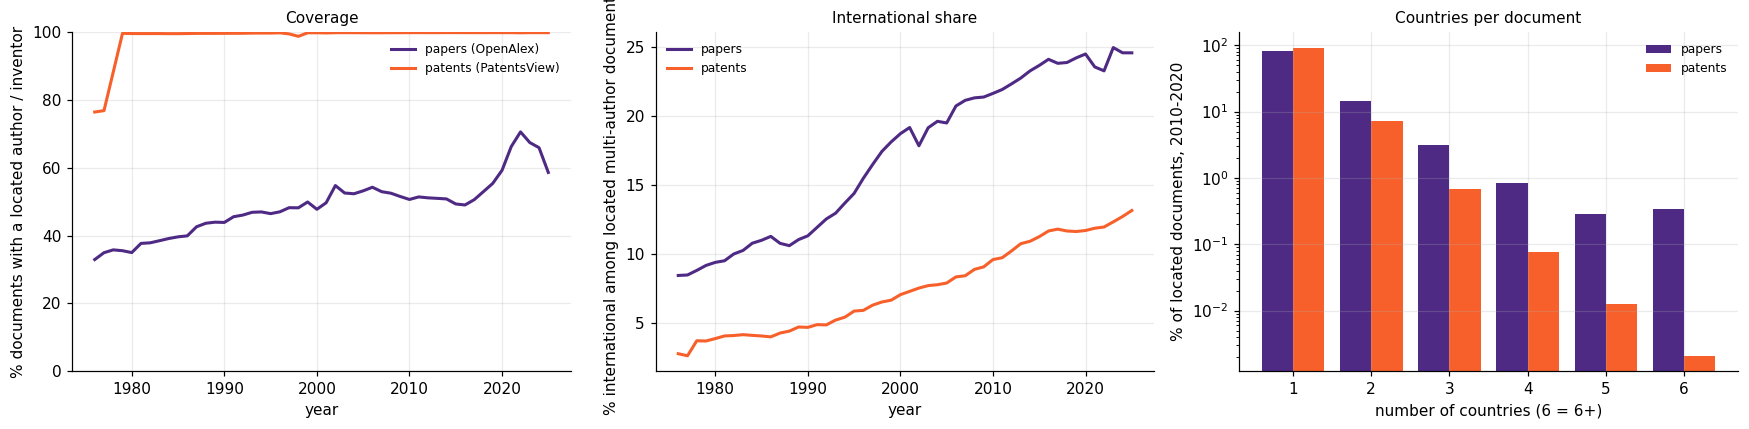

      located_paper  intl_paper  located_patent  intl_patent
year                                                        
1980           35.0         9.4            99.6          3.9
1990           43.9        11.3            99.7          4.7
2000           47.8        18.7            99.8          7.0
2010           50.7        21.6            99.9          9.6
2020           59.2        24.5            99.9         11.7
CPU times: user 14.2 s, sys: 296 ms, total: 14.5 s
Wall time: 5.34 s


In [9]:
%%time
if os.path.exists(PAPER_BASE):
    PB, src = f"read_parquet('{PAPER_BASE}')", f'{os.path.basename(PAPER_BASE)} (author_country_validation)'
elif os.path.exists(PAPER_AC) and os.path.exists(PAPER_META):
    PB = (f"(SELECT a.team_size, a.n_countries, a.countries, m.year::INTEGER AS year "
          f"FROM read_parquet('{PAPER_AC}') a JOIN read_parquet('{PAPER_META}') m USING (paper_id))")
    src = 'paper_author_country x paper_metadata (heavy join -- run author_country_validation first to avoid it)'
else:
    PB, src = None, None
    print('[skip 7] OpenAlex paper_author_country not present')

if PB:
    print('paper side from', src)
    pp = con.execute(f"""
    SELECT year, 100.0*count(countries)/count(*) AS located,
           100.0*count(*) FILTER (WHERE n_countries > 1 AND team_size >= 2)
                 /nullif(count(*) FILTER (WHERE countries IS NOT NULL AND team_size >= 2), 0) AS intl
    FROM {PB} WHERE year BETWEEN {YMIN} AND {YMAX} GROUP BY 1 ORDER BY 1""").fetchdf()
    pt = con.execute(f"""
    SELECT grant_year AS year, 100.0*count(countries)/count(*) AS located,
           100.0*count(*) FILTER (WHERE n_countries > 1 AND team_size >= 2)
                 /nullif(count(*) FILTER (WHERE countries IS NOT NULL AND team_size >= 2), 0) AS intl
    FROM base WHERE grant_year BETWEEN {YMIN} AND {YMAX} GROUP BY 1 ORDER BY 1""").fetchdf()
    dp = con.execute(f"""
    SELECT least(n_countries, 6) AS k, count(*) AS n FROM {PB}
    WHERE countries IS NOT NULL AND year BETWEEN 2010 AND 2020 GROUP BY 1 ORDER BY 1""").fetchdf()
    dt = con.execute("""
    SELECT least(n_countries, 6) AS k, count(*) AS n FROM base
    WHERE countries IS NOT NULL AND grant_year BETWEEN 2010 AND 2020 GROUP BY 1 ORDER BY 1""").fetchdf()

    fig, ax = plt.subplots(1, 3, figsize=(16, 4))
    ax[0].plot(pp.year, pp.located, color=C1, lw=2, label='papers (OpenAlex)')
    ax[0].plot(pt.year, pt.located, color=C2, lw=2, label='patents (PatentsView)')
    ax[0].set_ylim(0, 100); ax[0].set_ylabel('% documents with a located author / inventor')
    ax[0].set_title('Coverage', fontsize=10); ax[0].legend(frameon=False, fontsize=8); clean(ax[0])
    ax[1].plot(pp.year, pp.intl, color=C1, lw=2, label='papers')
    ax[1].plot(pt.year, pt.intl, color=C2, lw=2, label='patents')
    ax[1].set_ylabel('% international among located multi-author documents')
    ax[1].set_title('International share', fontsize=10); ax[1].legend(frameon=False, fontsize=8); clean(ax[1])
    ax[2].bar(dp.k - 0.2, 100 * dp.n / max(dp.n.sum(), 1), 0.4, color=C1, label='papers')
    ax[2].bar(dt.k + 0.2, 100 * dt.n / max(dt.n.sum(), 1), 0.4, color=C2, label='patents')
    ax[2].set_yscale('log'); ax[2].set_xlabel('number of countries (6 = 6+)')
    ax[2].set_ylabel('% of located documents, 2010-2020'); ax[2].set_title('Countries per document', fontsize=10)
    ax[2].legend(frameon=False, fontsize=8); clean(ax[2])
    for a in ax[:2]:
        a.set_xlabel('year')
    V.save('7')
    both = pd.merge(pp, pt, on='year', suffixes=('_paper', '_patent')).set_index('year')
    print(both.reindex([y for y in (1980, 1990, 2000, 2010, 2020) if y in both.index]).round(1).to_string())

## 8. The world map

The same four views as the author notebook's §9, on the same projection and the same colour
ramps, so the two families can be read side by side.

1. **Share of world patenting**, fractional counting, 2015–2020, log colour scale.
2. **International co-invention rate** — share of a country's located patents with inventors in
   ≥ 2 countries. Note the legend range: it is far narrower than the paper map, because
   cross-border invention is much rarer than cross-border authorship.
3. **Mean citation percentile**, 1990–2015, over countries with at least 500 scored patents.
4. **Change in share**, 2000–2005 → 2015–2020, log₂ of the ratio, diverging, clipped at ±2.

Grey is "no value", not zero, and panels 3 and 4 carry volume floors. Codes in the data with no
polygon are listed under the figure.

  [fig] inventor_country_validation_8.jpg + .pdf  (600 dpi)


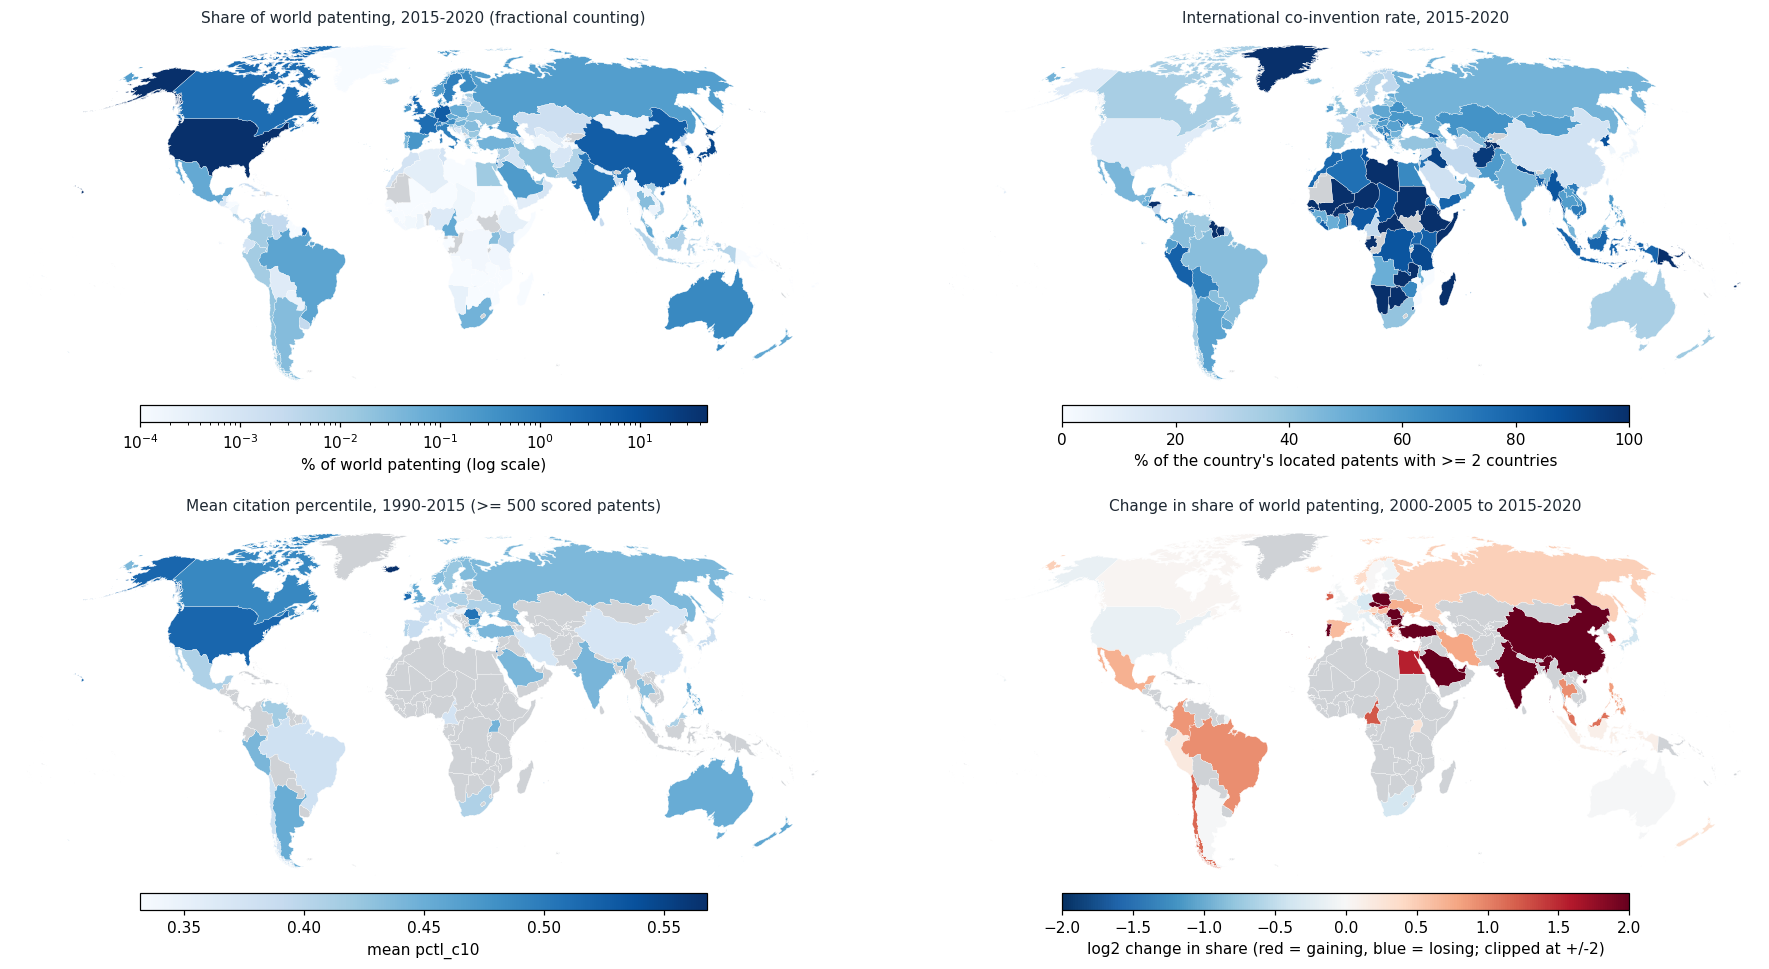

  1 inventor-country code(s) have no polygon on the map (0.00% of the total): GI
  panel 3 covers 53 countries, panel 4 57
          share    intl    hit  change
country                               
US       46.980  11.716  0.519  -0.156
JP       15.603   4.162  0.386  -0.396
KR        6.308   4.246  0.349   1.385
DE        5.249  23.868  0.385  -0.338
CN        4.800  19.038  0.371   3.730
TW        3.486   9.517  0.359   0.122
CA        2.161  34.642  0.488   0.046
GB        2.155  37.823  0.453  -0.056
FR        2.107  27.071  0.386  -0.122
IN        1.402  46.691  0.442   2.949
IL        1.282  25.847  0.519   1.049
IT        0.903  25.566  0.365  -0.173
SE        0.895  30.236  0.423   0.002
CH        0.853  46.544  0.407   0.097
NL        0.851  35.886  0.403   0.112
CPU times: user 41.9 s, sys: 1.16 s, total: 43.1 s
Wall time: 14.2 s


In [10]:
%%time
from matplotlib.colors import LogNorm, TwoSlopeNorm
world, PTS = load_world()
if world is None:
    print('[skip 8] no world geometry available')
else:
    cty = con.execute("""
    WITH x AS (
      SELECT grant_year, n_countries, pctl_c10,
             list_transform(str_split(country_inventor_counts, ';'), s -> str_split(s, ':')) AS L
      FROM base WHERE country_inventor_counts IS NOT NULL AND grant_year BETWEEN 1990 AND 2020),
    y AS (SELECT *, list_sum(list_transform(L, z -> z[2]::INTEGER)) AS tot FROM x)
    SELECT z[1] AS country,
           sum(CASE WHEN grant_year BETWEEN 2015 AND 2020 THEN z[2]::INTEGER / tot END) AS frac_recent,
           sum(CASE WHEN grant_year BETWEEN 2000 AND 2005 THEN z[2]::INTEGER / tot END) AS frac_early,
           count(*) FILTER (WHERE grant_year BETWEEN 2015 AND 2020)                     AS n_recent,
           100.0*avg(CASE WHEN n_countries > 1 THEN 1.0 ELSE 0.0 END)
                 FILTER (WHERE grant_year BETWEEN 2015 AND 2020)                        AS intl,
           avg(pctl_c10) FILTER (WHERE grant_year BETWEEN 1990 AND 2015)                AS hit,
           count(pctl_c10) FILTER (WHERE grant_year BETWEEN 1990 AND 2015)              AS n_hit
    FROM y, unnest(L) AS u(z) WHERE tot > 0 GROUP BY 1""").fetchdf().set_index('country')
    cty['share'] = 100 * cty.frac_recent / cty.frac_recent.sum()
    early = 100 * cty.frac_early / cty.frac_early.sum()
    cty['change'] = np.log2(cty.share / early)
    solid = cty[(cty.n_recent >= 200) & (cty.frac_early >= 20)]

    fig, axes = plt.subplots(2, 2, figsize=(17, 9))
    choropleth(axes[0, 0], world, cty.share, 'Share of world patenting, 2015-2020 (fractional counting)',
               '% of world patenting (log scale)',
               norm=LogNorm(vmin=max(cty.share[cty.share > 0].min(), 1e-4), vmax=cty.share.max()))
    choropleth(axes[0, 1], world, cty.intl, 'International co-invention rate, 2015-2020',
               '% of the country\'s located patents with >= 2 countries')
    choropleth(axes[1, 0], world, cty.hit[cty.n_hit >= 500],
               'Mean citation percentile, 1990-2015 (>= 500 scored patents)', 'mean pctl_c10')
    choropleth(axes[1, 1], world, solid.change.clip(-2, 2),
               'Change in share of world patenting, 2000-2005 to 2015-2020',
               'log2 change in share (red = gaining, blue = losing; clipped at +/-2)',
               cmap=DIV, norm=TwoSlopeNorm(vcenter=0, vmin=-2, vmax=2))
    V.save('8')
    map_coverage(cty.frac_recent.dropna(), world, 'inventor-country')
    print(f'  panel 3 covers {int((cty.n_hit >= 500).sum())} countries, panel 4 {len(solid)}')
    print(cty.loc[cty.share.nlargest(15).index, ['share', 'intl', 'hit', 'change']].round(3).to_string())

## 9. Where the co-invention actually goes

The 70 largest inventor-country pairs of 2010–2020 as great-circle arcs, width proportional to
the square root of the number of joint patents — the map twin of §5, and the direct counterpart
of the author notebook's §10. The structure is visibly different from the paper map: almost
every heavy arc lands in the United States, because this is the US patent record and a foreign
team appears in it mainly when it is filing alongside a US-based one.

  [fig] inventor_country_validation_9.jpg + .pdf  (600 dpi)


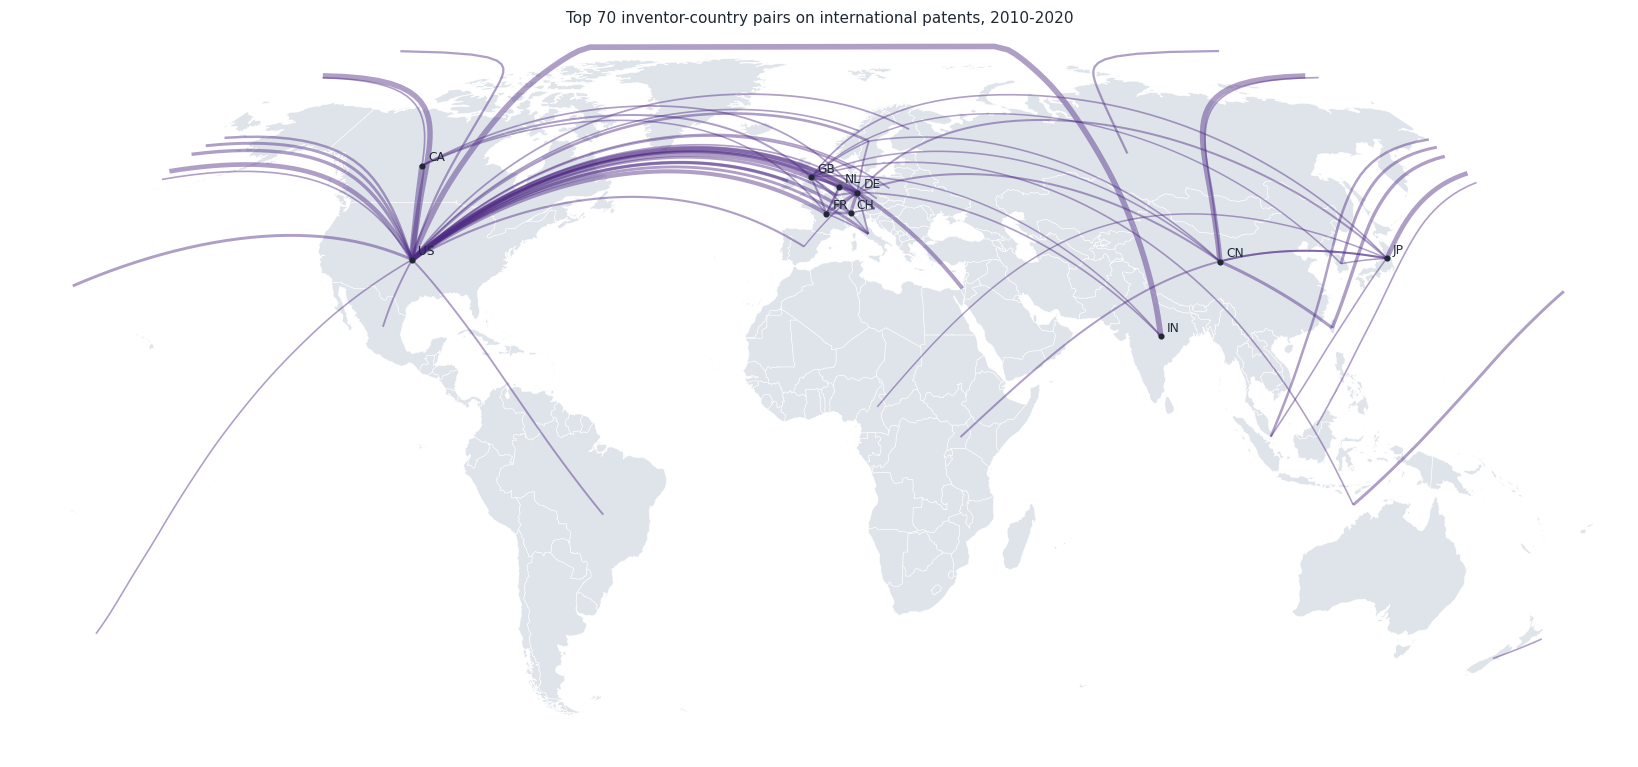

  the 70 arcs drawn carry 78.8% of all 313,004 country-pair occurrences in 2010-2020


CPU times: user 1.95 s, sys: 170 ms, total: 2.12 s
Wall time: 2.09 s


In [11]:
%%time
if world is None or not len(pairs):
    print('[skip 9] no world geometry or no pairs')
else:
    fig, ax = plt.subplots(figsize=(15, 7.5))
    flowmap(ax, world, PTS, pairs, 'Top 70 inventor-country pairs on international patents, 2010-2020')
    V.save('9')
    tot = pairs.n.sum()
    print(f'  the 70 arcs drawn carry {100*pairs.nlargest(70, "n").n.sum()/tot:.1f}% of all '
          f'{tot:,} country-pair occurrences in 2010-2020')
con.close()